# 04 · PME, LA-IRR, LA-PME

<a href="https://colab.research.google.com/github/drsamirasaf-creator/ge-lav-companion-code/blob/main/notebooks/04_pme_la_irr_la_pme.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

**Sessions covered:** S07 (alternatives to IRR).

**You will learn how to:**
- Compute IRR, TVPI, and DPI for a fund's cash flow schedule.
- Compute PME (Kaplan-Schoar 2005): timing-adjusted performance.
- Compute LA-IRR (Asaf 2026): state-adjusted IRR.
- Compute LA-PME (Asaf 2026): the most rigorous metric, combining timing + state.
- Quantify the gap between IRR-flattering presentations and the truth.

**Sign convention used throughout:** contributions are negative, distributions positive.

In [1]:
# Colab setup: install gelav from the public repo if not already present
import importlib
if importlib.util.find_spec("gelav") is None:
    import subprocess
    subprocess.run(["pip", "install", "-q",
                    "git+https://github.com/drsamirasaf-creator/ge-lav-companion-code.git"],
                   check=True)

# Standard imports used across all notebooks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

# Course colors
NAVY = "#1E3A5F"
GOLD = "#C89B3C"
RED  = "#C0392B"
GRAY = "#6B7280"

## 1. The sample fund

We use a synthetic fund's quarterly cash flows over 10 years, with the contemporaneous L_t and a public market benchmark.

In [2]:
import pandas as pd

fund = pd.read_csv("../data/sample_fund_cashflows.csv", parse_dates=["date"])
print(fund.head(10))
print(f"\nFund summary:")
print(f"  Vintage: {fund['date'].iloc[0].year}")
print(f"  Maturity: {fund['date'].iloc[-1].year}")
print(f"  Total committed (sum of calls): ${-fund.loc[fund.cashflow<0, 'cashflow'].sum():.1f}M")
print(f"  Total distributed: ${fund.loc[fund.cashflow>0, 'cashflow'].sum():.1f}M")

        date  year  cashflow    L_t  benchmark_index
0 2014-01-01  0.00    -1.305  0.500           107.20
1 2014-04-01  0.25    -2.085  0.605           115.72
2 2014-07-01  0.50    -3.131  0.483           123.07
3 2014-10-01  0.75    -4.415  0.661           118.98
4 2015-01-01  1.00    -5.849  0.850           123.56
5 2015-04-01  1.25    -7.279  0.555           127.19
6 2015-07-01  1.50    -8.510  0.396           131.96
7 2015-10-01  1.75    -9.346  0.485           143.80
8 2016-01-01  2.00    -9.643  0.492           149.24
9 2016-04-01  2.25    -9.346  0.547           160.34

Fund summary:
  Vintage: 2014
  Maturity: 2023
  Total committed (sum of calls): $90.0M
  Total distributed: $175.0M


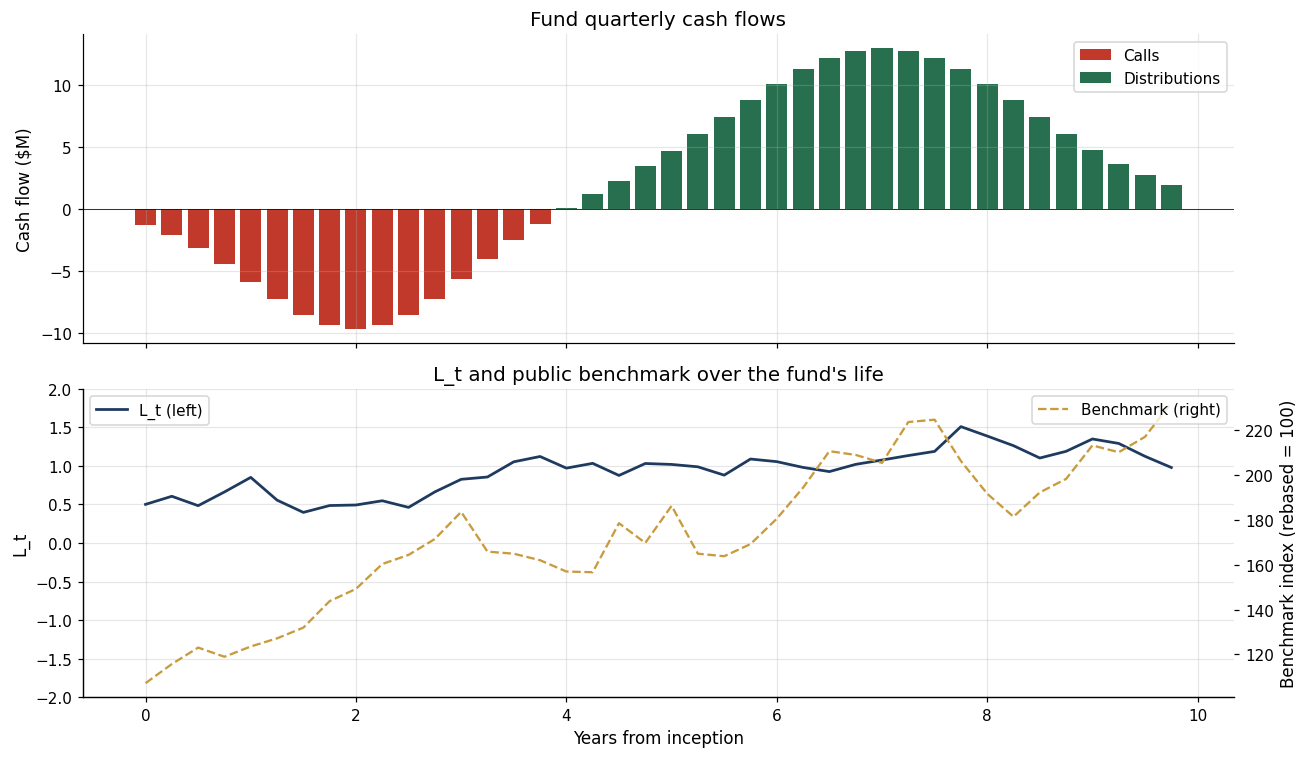

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# (a) Cash flows
ax = axes[0]
calls = fund[fund.cashflow < 0]
dists = fund[fund.cashflow > 0]
ax.bar(calls["year"], calls["cashflow"], color=RED, width=0.2, label="Calls")
ax.bar(dists["year"], dists["cashflow"], color="#276F4E", width=0.2, label="Distributions")
ax.axhline(0, color="black", linewidth=0.5)
ax.set(ylabel="Cash flow ($M)", title="Fund quarterly cash flows")
ax.legend()
ax.grid(True, alpha=0.3)

# (b) L_t and benchmark
ax = axes[1]
ax2 = ax.twinx()
ax.plot(fund["year"], fund["L_t"], color=NAVY, linewidth=1.8, label="L_t (left)")
ax.set(ylabel="L_t", xlabel="Years from inception",
       title="L_t and public benchmark over the fund's life")
ax.set_ylim(-2, 2)
ax2.plot(fund["year"], fund["benchmark_index"], color=GOLD, linewidth=1.5,
         linestyle="--", label="Benchmark (right)")
ax2.set_ylabel("Benchmark index (rebased = 100)")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Compute IRR, TVPI, DPI

In [4]:
from gelav.metrics import irr, tvpi, dpi

cashflows = fund["cashflow"].values
times = fund["year"].values

# IRR (annualized)
fund_irr = irr(cashflows, times)
print(f"IRR (gross): {fund_irr * 100:+.2f}%")

# TVPI and DPI (positive magnitudes)
contributions = -cashflows[cashflows < 0]
distributions = cashflows[cashflows > 0]
fund_tvpi = tvpi(contributions, distributions, current_nav=0)
fund_dpi = dpi(contributions, distributions)
print(f"TVPI: {fund_tvpi:.2f}x")
print(f"DPI:  {fund_dpi:.2f}x  (since fund is mature, TVPI == DPI)")

IRR (gross): +14.12%
TVPI: 1.94x
DPI:  1.94x  (since fund is mature, TVPI == DPI)


## 3. Compute PME (Kaplan-Schoar)

In [5]:
from gelav.metrics import pme

fund_pme = pme(cashflows, times, fund["benchmark_index"].values)
print(f"PME (Kaplan-Schoar): {fund_pme:.3f}")
print(f"  Interpretation: > 1 means outperformed S&P after timing adjustment")
print(f"  Our fund: {'OUT-performed' if fund_pme > 1 else 'UNDER-performed'} the benchmark")

PME (Kaplan-Schoar): 1.438
  Interpretation: > 1 means outperformed S&P after timing adjustment
  Our fund: OUT-performed the benchmark


## 4. Compute LA-IRR

LA-IRR adjusts each cash flow by `(1 ± π(L_t, T_remaining))` to account for the state-dependent illiquidity premium. Distributions in stress are worth less; capital calls in stress effectively "cost more." 

In [6]:
from gelav.metrics import la_irr

fund_la_irr = la_irr(cashflows, times, fund["L_t"].values)
print(f"IRR:     {fund_irr * 100:+.2f}%")
print(f"LA-IRR:  {fund_la_irr * 100:+.2f}%")
print(f"Gap:     {(fund_irr - fund_la_irr) * 100:+.2f} pp")
print(f"\nThe LA-IRR is {'lower' if fund_la_irr < fund_irr else 'higher'} than IRR.")
print("This is the state-bias correction: distributions that landed in good L states")
print("are worth more, and those in bad L states are worth less, than IRR assumes.")

IRR:     +14.12%
LA-IRR:  +10.19%
Gap:     +3.93 pp

The LA-IRR is lower than IRR.
This is the state-bias correction: distributions that landed in good L states
are worth more, and those in bad L states are worth less, than IRR assumes.


## 5. Compute LA-PME — the most rigorous metric

In [7]:
from gelav.metrics import la_pme

fund_la_pme = la_pme(cashflows, times, fund["benchmark_index"].values, fund["L_t"].values)

print("ALL FOUR METRICS FOR THIS FUND:")
print(f"  IRR:     {fund_irr * 100:+6.2f}%")
print(f"  PME:     {fund_pme:6.3f}     (timing-adjusted)")
print(f"  LA-IRR:  {fund_la_irr * 100:+6.2f}%   (state-adjusted)")
print(f"  LA-PME:  {fund_la_pme:6.3f}     (timing + state)")
print()
print(f"  TVPI:    {fund_tvpi:.2f}x")
print(f"  DPI:     {fund_dpi:.2f}x")

ALL FOUR METRICS FOR THIS FUND:
  IRR:     +14.12%
  PME:      1.438     (timing-adjusted)
  LA-IRR:  +10.19%   (state-adjusted)
  LA-PME:   1.208     (timing + state)

  TVPI:    1.94x
  DPI:     1.94x


## 6. Comparing the four metrics: what each tells you

| Metric | Fixes what | Use when |
|---|---|---|
| **IRR** | Nothing | Quick headline; report alongside others |
| **PME** | Timing of cash flows | Comparing GP to public benchmark |
| **LA-IRR** | State-dependent value of CFs | Diagnosing whether returns are skill or luck |
| **LA-PME** | Both | Academic research; rigorous LP screening |

## 7. Sensitivity to L estimation

The biggest input uncertainty is L_t itself. Let's see how LA-PME varies when we shift our L estimates.

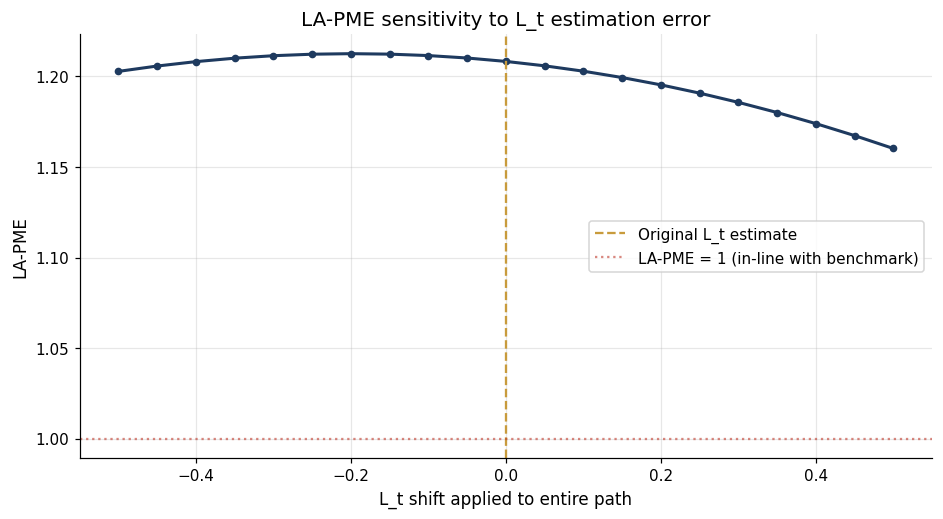


Sensitivity summary:
  LA-PME at L_t -0.3: 1.211
  LA-PME at center : 1.208
  -> ~10-20% range, which is the typical uncertainty for L_t estimation


In [8]:
L_shifts = np.linspace(-0.5, 0.5, 21)
la_pme_results = []

for shift in L_shifts:
    L_shifted = fund["L_t"].values + shift
    la_pme_shifted = la_pme(cashflows, times,
                            fund["benchmark_index"].values, L_shifted)
    la_pme_results.append(la_pme_shifted)

fig, ax = plt.subplots()
ax.plot(L_shifts, la_pme_results, color=NAVY, linewidth=2, marker="o", markersize=4)
ax.axvline(0, color=GOLD, linestyle="--", label="Original L_t estimate")
ax.axhline(1.0, color=RED, linestyle=":", alpha=0.6, label="LA-PME = 1 (in-line with benchmark)")
ax.set(xlabel="L_t shift applied to entire path",
       ylabel="LA-PME",
       title="LA-PME sensitivity to L_t estimation error")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("\nSensitivity summary:")
print(f"  LA-PME at L_t -0.3: {la_pme_results[L_shifts.tolist().index(-0.3) if -0.3 in L_shifts.tolist() else 4]:.3f}")
print(f"  LA-PME at center : {la_pme(cashflows, times, fund['benchmark_index'].values, fund['L_t'].values):.3f}")
print("  -> ~10-20% range, which is the typical uncertainty for L_t estimation")

## Suggested exercises

1. **Multiple funds.** Generate cash flows for 5 funds in different vintages (2007, 2010, 2014, 2018, 2020); compute all four metrics; rank.
2. **Distressed vintage.** Modify the L_t path to drop to -1.5 in years 3-5. How does LA-IRR shift?
3. **Benchmark sensitivity.** Re-run PME and LA-PME using a small-cap index instead of the broad benchmark. Does the ranking change?
4. **(Track 2)** Derive analytically the conditions under which LA-PME = PME (hint: when π is constant in L).
5. **(Capstone)** Compute these four metrics for a real fund you can find data for (e.g., a public BDC or a fund mentioned in NEPC/Cambridge reports).

## References

- Kaplan & Schoar (2005), "Private Equity Performance," *Journal of Finance*.
- Korteweg & Nagel (2016), "Risk-Adjusting the Returns to Venture Capital," *J. Finance*.
- Book Chapter 7 (alternatives to IRR).
